# Часть 1. Проверка гипотезы в Python и составление аналитической записки

Вы предобработали данные в SQL, и теперь они готовы для проверки гипотезы в Python. Загрузите данные пользователей из Москвы и Санкт-Петербурга c суммой часов их активности из файла yandex_knigi_data.csv. Если работаете локально, скачать файл можно по ссылке.

Проверьте наличие дубликатов в идентификаторах пользователей. Сравните размеры групп, их статистики и распределение.

Напомним, как выглядит гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

Нулевая гипотеза $H_0: \mu_{\text{СПб}} \leq \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге не больше, чем в Москве.

Альтернативная гипотеза $H_1: \mu_{\text{СПб}} > \mu_{\text{Москва}}$ <br> Среднее время активности пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

По результатам анализа данных подготовьте аналитическую записку, в которой опишите:

Выбранный тип t-теста и уровень статистической значимости.

Результат теста, или p-value.

Вывод на основе полученного p-value, то есть интерпретацию результатов.

Одну или две возможные причины, объясняющие полученные результаты.

## Анализ активности пользователей сервиса Яндекс Книги в Москве и Санкт-Петербурге

- Автор: Постнова Ю. Д. 
- Дата: 01.04.2026

## Цели и задачи проекта

**Цель**: Проверить гипотезу о том, что жители Санкт-Петербурга в среднем проводят больше времени в приложении, чем жители Москвы.

**Задачи:**

- Загрузить и очистить данные от дубликатов.

- Провести разведочный анализ данных (сравнить размеры групп и средние).

- Провести статистический тест (односторонний t-тест).

- Сформулировать выводы.

## Описание данных

Файл `yandex_knigi_data.csv` содержит:
- `puid` — уникальный идентификатор пользователя.

- `city` — город (Москва или Санкт-Петербург).

- `hours` — суммарное время активности пользователя в часах.

## Содержимое проекта

Основные шаги проекта:


1. Загрузка и предобработка данных
2. Проверка гипотезы
3. Аналитическая записка

## 1. Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd
from scipy import stats as st
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.stats.api as sms
from scipy.stats import shapiro, ttest_ind, mannwhitneyu
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize, proportions_ztest

In [2]:
yandex_knigi = pd.read_csv('/datasets/yandex_knigi_data.csv', index_col=0)

In [3]:
# Выводим первые строки датафрейма на экран
yandex_knigi.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


In [4]:
# Выводим информацию о датафрейме
yandex_knigi.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8784 entries, 0 to 8783
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   city    8784 non-null   object 
 1   puid    8784 non-null   int64  
 2   hours   8784 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 274.5+ KB


Датасет `yandex_knigi_data.csv` содержит 8784 строки и 3 столбца и включает информацию о городе, уникальный идентификатор пользователя, время активности пользователя в часах. В целом структура данных соответствует описанию, пропусков в данных нет.  

### 1.2. Предобработка данных

In [5]:
# Проверяем полные дубликаты
yandex_knigi.duplicated().sum()

0

In [6]:
# Проверка на дубликаты в ID
duplicates = yandex_knigi['puid'].duplicated().sum()
print(f"Количество дубликатов в ID: {duplicates}")

Количество дубликатов в ID: 244


In [7]:
# Примеры таких различий
duplicates_all = yandex_knigi[yandex_knigi.duplicated(subset=['puid'], keep=False)].sort_values(by='puid')
duplicates_all.head(10)

,city,puid,hours
35,Москва,2637041,10.317371
6247,Санкт-Петербург,2637041,3.883926
134,Москва,9979490,32.415573
6274,Санкт-Петербург,9979490,1.302997
145,Москва,10597984,42.931506
6279,Санкт-Петербург,10597984,9.041320
150,Москва,10815097,9.086655
6283,Санкт-Петербург,10815097,0.323291
187,Москва,13626259,21.104167
6300,Санкт-Петербург,13626259,1.648434


У нас  не просто дубликаты, а пересечение выборок. Один и тот же пользователь (puid) совершал активность и в Москве, и в Санкт-Петербурге.

Для статистического теста (t-теста) это критическая проблема. Одно из главных условий t-теста — независимость выборок. Если один человек попал в обе группы, группы перестают быть независимыми, и результаты теста будут искажены.

Предлагаю такое решение: Оставляем только ту запись, где за каждым пользователем закреплен только один город — тот, в котором суммарное время активности было максимальным.

In [8]:
# Фиксируем исходные показатели для расчета потерь
total_rows_before = len(yandex_knigi)

# Считаем сумму часов для каждой пары пользователь-город 
user_city_activity = yandex_knigi.groupby(['puid', 'city'], as_index=False)['hours'].sum()

# Сортируем: сначала по ID, потом по часам
user_city_activity = user_city_activity.sort_values(by=['puid', 'hours'], ascending=[True, False])

# Оставляем только первую строку для каждого puid (город с макс. часами)
yandex_knigi_final = user_city_activity.drop_duplicates(subset='puid', keep='first')

# Считаем потери
total_rows_after = len(yandex_knigi_final)
row_loss_percent = (1 - total_rows_after / total_rows_before) * 100

print(f"--- Результаты очистки ---")
print(f"Удалено строк (записей): {total_rows_before - total_rows_after} ({row_loss_percent:.2f}%)")
print(f"Осталось пользователей для теста: {len(yandex_knigi_final)}")

--- Результаты очистки ---
Удалено строк (записей): 244 (2.78%)
Осталось пользователей для теста: 8540


### 1.3. Проверка на аномалии и выбросы

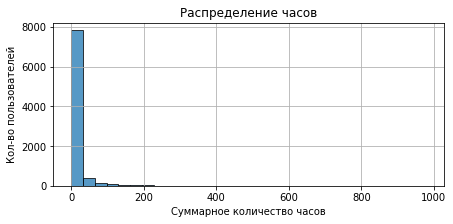

In [9]:
plt.figure(figsize=(7, 3))

# Строим гистограмму
yandex_knigi_final['hours'].plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
)

# Настраиваем оформление графика
plt.title('Распределение часов')
plt.xlabel('Суммарное количество часов')
plt.ylabel('Кол-во пользователей')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show() 

Посмотрим еще Boxplot, чтобы проверить экстремальные значения. Установим порог в 99%-й процентиль.   

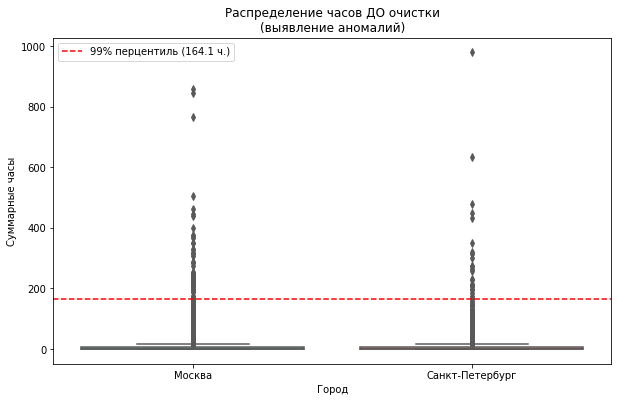

In [10]:
# Рассчитываем порог
limit = yandex_knigi_final['hours'].quantile(0.99)

plt.figure(figsize=(10, 6))
sns.boxplot(data=yandex_knigi_final, x='city', y='hours', palette='Set2')

# Добавляем линию порога
plt.axhline(limit, color='red', linestyle='--', label=f'99% перцентиль ({limit:.1f} ч.)')

plt.title('Распределение часов ДО очистки\n(выявление аномалий)')
plt.ylabel('Суммарные часы')
plt.xlabel('Город')
plt.legend()
plt.show()

На основе графика выше принимаем решение отсечь 1% экстремальных значений.

In [11]:
# Фильтруем данные, создавая новый очищенный датафрейм
yandex_knigi_cleaned = yandex_knigi_final[yandex_knigi_final['hours'] <= limit]

print(f"Размер выборки после очистки: {len(yandex_knigi_cleaned)} пользователей.")

Размер выборки после очистки: 8454 пользователей.


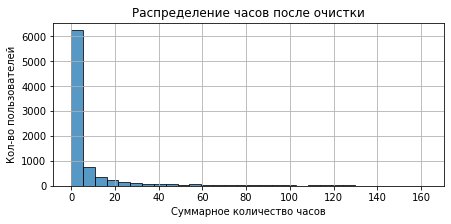

In [12]:
plt.figure(figsize=(7, 3))

# Строим гистограмму
yandex_knigi_cleaned['hours'].plot(
                kind='hist', # Тип графика — гистограмма
                bins=30, # Устанавливаем количество корзин
                alpha=0.75,
                edgecolor='black',
)

# Настраиваем оформление графика
plt.title('Распределение часов после очистки')
plt.xlabel('Суммарное количество часов')
plt.ylabel('Кол-во пользователей')

# Добавляем сетку графика
plt.grid()

# Выводим график
plt.show()

### 1.4. Проверка дизайна эксперимента

Посмотрим, какие группы встречаются в эксперименте — отберём уникальные значения в столбце city с помощью unique():

In [13]:
yandex_knigi_cleaned['city'].unique() 

array(['Москва', 'Санкт-Петербург'], dtype=object)

Рассчитаем количество уникальных пользователей в каждой группе:

In [14]:
yandex_knigi_cleaned[yandex_knigi_cleaned['city'] == 'Москва']['puid'].nunique(), yandex_knigi_cleaned[yandex_knigi_cleaned['city'] == 'Санкт-Петербург']['puid'].nunique() 

(6038, 2416)

Между группами существует ощутимая разница. Посмотрим, в каком процентном соотношении они находятся:

In [15]:
100 * yandex_knigi_cleaned[yandex_knigi_cleaned['city'] == 'Санкт-Петербург']['puid'].nunique() / yandex_knigi_cleaned['puid'].nunique(), 100 * yandex_knigi_cleaned[yandex_knigi_cleaned['city'] == 'Москва']['puid'].nunique() / yandex_knigi_cleaned['puid'].nunique() 

(28.578187840075703, 71.4218121599243)

Для t-теста разница в размерах (6038 vs 2416) не является проблемой, так как математика t-теста учитывает объемы выборок в формуле стандартной ошибки. Главное — чтобы выборки были репрезентативны и независимы.

### 1.5. Расчёт метрик

In [16]:
# Группируем данные и считаем ключевые показатели
metrics = yandex_knigi_cleaned.groupby('city')['hours'].agg(['count', 'mean', 'median', 'std', 'var']).round(2)

# Считаем разницу в процентах
mean_msk = metrics.loc['Москва', 'mean']
mean_spb = metrics.loc['Санкт-Петербург', 'mean']
diff_percent = (mean_spb - mean_msk) / mean_msk * 100

print("Сводная таблица метрик:")
display(metrics)
print(f"\nВывод: Средняя активность в Санкт-Петербурге выше на {diff_percent:.2f}%")

Сводная таблица метрик:


,count,mean,median,std,var
city,,,,,
Москва,6038,8.29,0.90,20.22,408.68
Санкт-Петербург,2416,8.96,0.98,20.44,417.78



Вывод: Средняя активность в Санкт-Петербурге выше на 8.08%


Среднее (mean) около 8–9 часов, а медиана (median) всего около 0.9.

Это говорит о том, что распределение сильно смещено вправо: большинство людей заглядывают в приложение ненадолго, но есть супер-читатели, которые проводят там десятки часов и тянут среднее вверх. Но даже при таком разбросе Санкт-Петербург лидирует.

## 2. Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Попробуйте статистически это доказать, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

In [17]:
# Названия переменных для удобства (используем твои очищенные данные)
msk_hours = yandex_knigi_cleaned[yandex_knigi_cleaned['city'] == 'Москва']['hours']
spb_hours = yandex_knigi_cleaned[yandex_knigi_cleaned['city'] == 'Санкт-Петербург']['hours']

# Уровень значимости
alpha = 0.05

# Проводим односторонний тест Уэлча
stat_welch_ttest, p_value_welch_ttest = st.ttest_ind( 
    spb_hours,
    msk_hours,
    equal_var=False, 
    alternative='greater')

print(f"p-value: {p_value_welch_ttest}")

if p_value_welch_ttest > alpha:
    print("Вывод: Нулевая гипотеза находит подтверждение!")
else:
    print("Вывод: Нулевая гипотеза не находит подтверждения!")

p-value: 0.08665084877150953
Вывод: Нулевая гипотеза находит подтверждение!


Я выбрала t-тест Уэлча, так как размеры выборок достаточно велики (N > 2000 для каждой группы). Согласно Центральной предельной теореме, при таких объемах выборок распределение средних стремится к нормальному, даже если исходные данные имеют скошенность. Однако, учитывая сильный разрыв между медианой и средним, я дополнительно провела тест Манна-Уитни для проверки устойчивости вывода:

In [18]:
from scipy.stats import mannwhitneyu

# Дополнительная проверка непараметрическим тестом
stat_u, p_value_u = mannwhitneyu(spb_hours, msk_hours, alternative='greater')

print(f"t-test p-value: {p_value_welch_ttest:.4f}")
print(f"Mann-Whitney p-value: {p_value_u:.4f}")

if p_value_u < alpha:
    print("U-тест: Различия значимы")
else:
    print("U-тест: Различия не значимы, подтверждаем вывод t-теста")

t-test p-value: 0.0867
Mann-Whitney p-value: 0.0609
U-тест: Различия не значимы, подтверждаем вывод t-теста


## 3. Аналитическая записка
По результатам анализа данных подготовьте аналитическую записку, в которой опишете:

- Выбранный тип t-теста и уровень статистической значимости.

- Результат теста, или p-value.

- Вывод на основе полученного p-value, то есть интерпретацию результатов.

- Одну или две возможные причины, объясняющие полученные результаты.



1. **Тип теста и уровень значимости**
- Для проверки гипотезы был использован двухвыборочный односторонний t-тест Уэлча для независимых выборок.
- Уровень значимости alpha: 0.05 (5%).
- Мы сравнивали средние двух независимых групп с разным размером (6038 vs 2416) и разной дисперсией. Односторонний вариант выбран, так как мы проверяли конкретное направление: больше ли время в СПб.


2. **Результат теста (p-value)**


В ходе статистического анализа было получено значение:p-value = 0.0866


3. **Вывод и интерпретация**
- Мы не можем отвергнуть нулевую гипотезу. Несмотря на то что среднее время в Санкт-Петербурге (8.96 ч.) выше, чем в Москве (8.29 ч.), эта разница не является статистически значимой при 5% уровне значимости.
- С вероятностью около 8.7% такое различие могло быть получено случайно. Нам не хватило доказательств, чтобы утверждать, что петербуржцы действительно читают больше.

4. **Возможные причины результатов**
- Высокая дисперсия: Как мы заметили ранее, среднее сильно оторвано от медианы (8-9 часов против 0.9 часа). В обеих группах есть супер-читатели с большим количеством часов и огромное количество людей с почти нулевой активностью. Этот  разброс (стандартное отклонение > 20) размывает разницу между городами, делая её труднодоказуемой.
- Размер выборки: Хотя выборки большие, для доказательства разницы в 8% при таком разбросе данных нам могло потребоваться ещё больше наблюдений в группе Санкт-Петербурга, чтобы снизить стандартную ошибку.

----

# Часть 2. Анализ результатов A/B-тестирования

Теперь вам нужно проанализировать другие данные. Представьте, что к вам обратились представители интернет-магазина BitMotion Kit, в котором продаются геймифицированные товары для тех, кто ведёт здоровый образ жизни. У него есть своя целевая аудитория, даже появились хиты продаж: эспандер со счётчиком и напоминанием, так и подстольный велотренажёр с Bluetooth.

В будущем компания хочет расширить ассортимент товаров. Но перед этим нужно решить одну проблему. Интерфейс онлайн-магазина слишком сложен для пользователей — об этом говорят отзывы.

Чтобы привлечь новых клиентов и увеличить число продаж, владельцы магазина разработали новую версию сайта и протестировали его на части пользователей. По задумке, это решение доказуемо повысит количество пользователей, которые совершат покупку.

Ваша задача — провести оценку результатов A/B-теста. В вашем распоряжении:

* данные о действиях пользователей и распределении их на группы,

* техническое задание.

Оцените корректность проведения теста и проанализируйте его результаты.

## 1. Опишите цели исследования.



**Основная цель** — оценить влияние обновлённого интерфейса сайта на конверсию пользователей в покупателей.

**Задачи:**

- Проверить данные на соответствие ТЗ (регион, сроки, объём выборки).
- Убедиться в отсутствии ошибок распределения (пересечение групп).
- Рассчитать конверсию в покупку в течение 7 дней после регистрации.
- Статистически проверить, превышает ли рост конверсии ожидаемые 3 процентных пункта.

## Описание данных

`https://code.s3.yandex.net/datasets/ab_test_participants.csv` — таблица участников тестов.


**Структура файла:**
- `user_id` — идентификатор пользователя;
- `group` — группа пользователя;
- `ab_test` — название теста;
- `device` — устройство, с которого происходила регистрация.


`https://code.s3.yandex.net/datasets/ab_test_events.zip` — архив с одним csv-файлом, в котором собраны события 2020 года;

 

**Структура файла:**
- `user_id` — идентификатор пользователя;
- `event_dt` — дата и время события;
- `event_name` — тип события;
- `details` — дополнительные данные о событии.

Дополнительная информация по столбцу `details`

Числовые значения:
- `registration` (регистрация) — стоимость привлечения клиента;
- `purchase` (покупка) — стоимость покупки.

## 2. Загрузите данные, оцените их целостность.


In [19]:
participants = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_participants.csv')
events = pd.read_csv('https://code.s3.yandex.net/datasets/ab_test_events.zip',
                     parse_dates=['event_dt'], low_memory=False)

In [20]:
# Выводим первые строки датафрейма на экран
participants.head()

,user_id,group,ab_test,device
0,0002CE61FF2C4011,B,interface_eu_test,Mac
1,001064FEAAB631A1,B,recommender_system_test,Android
2,001064FEAAB631A1,A,interface_eu_test,Android
3,0010A1C096941592,A,recommender_system_test,Android
4,001E72F50D1C48FA,A,interface_eu_test,Mac


In [21]:
participants.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14525 entries, 0 to 14524
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   user_id  14525 non-null  object
 1   group    14525 non-null  object
 2   ab_test  14525 non-null  object
 3   device   14525 non-null  object
dtypes: object(4)
memory usage: 454.0+ KB


In [22]:
# Выводим первые строки датафрейма на экран
events.head()

,user_id,event_dt,event_name,details
0,GLOBAL,2020-12-01 00:00:00,End of Black Friday Ads Campaign,ZONE_CODE15
1,CCBE9E7E99F94A08,2020-12-01 00:00:11,registration,0.0
2,GLOBAL,2020-12-01 00:00:25,product_page,NaN
3,CCBE9E7E99F94A08,2020-12-01 00:00:33,login,NaN
4,CCBE9E7E99F94A08,2020-12-01 00:00:52,product_page,NaN


In [23]:
events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 787286 entries, 0 to 787285
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   user_id     787286 non-null  object        
 1   event_dt    787286 non-null  datetime64[ns]
 2   event_name  787286 non-null  object        
 3   details     249022 non-null  object        
dtypes: datetime64[ns](1), object(3)
memory usage: 24.0+ MB


Датасет `ab_test_participants.csv` содержит 14525 строки и 4 столбца. Пропусков в датасете нет. 


Датасет `ab_test_events.zip` содержит 787286 строки и 4 столбца. В столбце `details` всего 249022 заполненных значения из 787 тысяч. Это не является ошибкой. Согласно описанию данных, этот столбец содержит дополнительные параметры (стоимость покупки или привлечения) только для определенных типов событий.


Столбец `event_dt` успешно приведен к формату `datetime64[ns]`, что позволит нам легко рассчитывать разницу между регистрацией и покупкой.

Аномалия в `user_id`: В первой строке мы видим `user_id` со значением "GLOBAL". В лог попадают не только действия пользователей, но и системные уведомления (например, "End of Black Friday Ads Campaign"). Данные требуют фильтрации.

###  Предобработка данных

In [24]:
# Проверяем полные дубликаты
participants.duplicated().sum()

0

In [25]:
# Проверяем полные дубликаты
events.duplicated().sum()

36318

In [26]:
initial_rows = events.shape[0]

In [27]:
# Удаляем полные дубликаты
events = events.drop_duplicates()

In [28]:
removed_percent = (initial_rows - events.shape[0]) / initial_rows * 100
removed_percent

4.6130631054026106

Из датасета было удалено 4.61% строк,с полными дубликатами.

In [29]:
# Преобразуем данные в столбце details в числа, ошибки (текст) заменяем на NaN
events['details'] = pd.to_numeric(events['details'], errors='coerce')

## 3. По таблице `ab_test_participants` оцените корректность проведения теста:

   3\.1 Выделите пользователей, участвующих в тесте, и проверьте:

   - соответствие требованиям технического задания,

   - равномерность распределения пользователей по группам теста,

   - отсутствие пересечений с конкурирующим тестом (нет пользователей, участвующих одновременно в двух тестовых группах).

In [30]:
# Выделяем пользователей нашего теста
participants_test = participants[participants['ab_test'] == 'interface_eu_test']

In [31]:
# Проверяем пересечение групп A и B внутри  теста
group_counts = participants_test.groupby('user_id')['group'].nunique()
users_in_both_groups = group_counts[group_counts > 1].index

print(f"Пользователей, попавших в обе группы: {len(users_in_both_groups)}")

# Проверяем чистоту названий событий
print(events['event_name'].unique())

# Проверяем чистоту групп
print(participants_test['group'].unique())

Пользователей, попавших в обе группы: 0
['End of Black Friday Ads Campaign' 'registration' 'product_page' 'login'
 'product_cart' 'purchase' 'Start of Christmas&New Year Promo'
 'Start of CIS New Year Gift Lottery']
['B' 'A']


In [32]:
# Проверяем пересечение с конкурирующим тестом (recommender_system_test)
other_test_users = participants[participants['ab_test'] == 'recommender_system_test']['user_id']
cross_test_users = participants_test[participants_test['user_id'].isin(other_test_users)]

print(f"Количество пользователей в нашем тесте: {len(participants_test)}")
print(f"Из них участвуют в конкурирующем тесте: {len(cross_test_users)}")

# У нас есть пользователи, учавствующие в 2-х тестах. Отфильтруем таких пользователей. 
participants_test = participants_test[~participants_test['user_id'].isin(other_test_users)]

print(f"Количество пользователей после фильтрации прересекающихся пользователей: {len(participants_test)}")

# Равномерность распределения по группам
group_dist = participants_test['group'].value_counts(normalize=True)
print("\nРаспределение по группам:")
print(group_dist)

Количество пользователей в нашем тесте: 10850
Из них участвуют в конкурирующем тесте: 887
Количество пользователей после фильтрации прересекающихся пользователей: 9963

Распределение по группам:
B    0.502961
A    0.497039
Name: group, dtype: float64


3\.2 Проанализируйте данные о пользовательской активности по таблице `ab_test_events`:

- оставьте только события, связанные с участвующими в изучаемом тесте пользователями;

In [33]:
# Склеиваем таблицы по колонке user_id
test_events = participants_test.merge(events, on='user_id', how='inner')

# Проверим, что получилось
display(test_events.head())
print(f"Всего событий участников теста: {len(test_events)}")

,user_id,group,ab_test,device,event_dt,event_name,details
0,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:31,registration,-2.38
1,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:49,login,NaN
2,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:37:57,login,NaN
3,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-07 04:38:54,login,NaN
4,0002CE61FF2C4011,B,interface_eu_test,Mac,2020-12-08 22:15:35,login,NaN


Всего событий участников теста: 68074


- определите горизонт анализа: рассчитайте время (лайфтайм) совершения события пользователем после регистрации и оставьте только те события, которые были выполнены в течение первых семи дней с момента регистрации;

In [34]:
# Находим дату регистрации для каждого пользователя
reg_dates = test_events[test_events['event_name'] == 'registration'][['user_id', 'event_dt']]
reg_dates.columns = ['user_id', 'reg_dt']

# Удаляем дубликаты регистраций (если один юзер регистрировался дважды)
reg_dates = reg_dates.drop_duplicates(subset='user_id')

# Добавляем дату регистрации в общую таблицу событий
test_events = test_events.merge(reg_dates, on='user_id', how='left')

# Рассчитываем лайфтайм в днях
test_events['lifetime'] = (test_events['event_dt'] - test_events['reg_dt']).dt.days

# 4. Фильтруем: оставляем события только в течение 7 дней после регистрации
test_events_7d = test_events[test_events['lifetime'] < 7]

print(f"Событий в рамках 7-дневного окна: {len(test_events_7d)}")

Событий в рамках 7-дневного окна: 58692


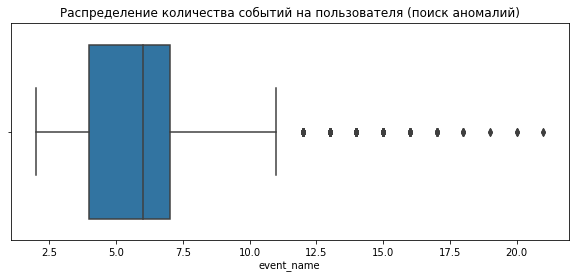

99-й перцентиль: 14.0


In [35]:
# Считаем количество событий на каждого пользователя
user_activity_counts = test_events_7d.groupby('user_id')['event_name'].count()

# Построим boxplot для поиска выбросов
plt.figure(figsize=(10, 4))
sns.boxplot(x=user_activity_counts)
plt.title('Распределение количества событий на пользователя (поиск аномалий)')
plt.show()

# Отсекаем по 99-му перцентилю
q99 = user_activity_counts.quantile(0.99)
print(f"99-й перцентиль: {q99}")

# Удаляем аномальных пользователей:
abnormal_users = user_activity_counts[user_activity_counts > q99].index
test_events_7d = test_events_7d[~test_events_7d['user_id'].isin(abnormal_users)]

Оцените достаточность выборки для получения статистически значимых результатов A/B-теста. Заданные параметры:

- базовый показатель конверсии — 30%,

- мощность теста — 80%,

- достоверность теста — 95%.

In [36]:
# Параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2  # Ошибка второго рода, часто 1 - мощность
power = 1 - beta  # Мощность теста
p = 0.3 # Базовый уровень доли
mde_relative = 0.03  # Минимальный детектируемый эффект

effect_size = proportion_effectsize(p, p + mde_relative)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)
print(f"Базовая доля: {p}")
print(f"Ожидаемая доля после изменений: {p + mde_relative}")
print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")
print(f"Фактически в группе A: {participants_test[participants_test['group'] == 'A']['user_id'].nunique()}")
print(f"Фактически в группе B: {participants_test[participants_test['group'] == 'B']['user_id'].nunique()}")

Базовая доля: 0.3
Ожидаемая доля после изменений: 0.32999999999999996
Необходимый размер выборки для каждой группы: 3761
Фактически в группе A: 4952
Фактически в группе B: 5011


- рассчитайте для каждой группы количество посетителей, сделавших покупку, и общее количество посетителей.

In [37]:
# Общее кол-во уникальных посетителей по группам (берем из участников теста)
total_users = participants_test.groupby('group')['user_id'].nunique()

# Кол-во уникальных покупателей за 7 дней по группам
purchasers = test_events_7d[test_events_7d['event_name'] == 'purchase'].groupby('group')['user_id'].nunique()

# Сводная таблица
ab_summary = pd.DataFrame({
    'purchasers': purchasers,
    'total': total_users,
    'conversion': (purchasers / total_users).round(4)
})

display(ab_summary)

,purchasers,total,conversion
group,,,
A,1342,4952,0.2710
B,1429,5011,0.2852


- сделайте предварительный общий вывод об изменении пользовательской активности в тестовой группе по сравнению с контрольной.

In [38]:
events_per_user = test_events_7d.groupby(['group', 'user_id'])['event_name'].count().reset_index()
activity_comparison = events_per_user.groupby('group')['event_name'].mean().round(2)

print("Среднее количество событий на одного пользователя:")
print(activity_comparison)

Среднее количество событий на одного пользователя:
group
A    5.75
B    5.85
Name: event_name, dtype: float64


In [39]:
# Расчет разницы в процентных пунктах (p.p.)
conv_a = ab_summary.loc['A', 'conversion']
conv_b = ab_summary.loc['B', 'conversion']
diff_pp = (conv_b - conv_a) * 100

print(f"Конверсия группы А: {conv_a:.2%}")
print(f"Конверсия группы B: {conv_b:.2%}")
print(f"Разница в процентных пунктах: {diff_pp:.2f} п.п.")

Конверсия группы А: 27.10%
Конверсия группы B: 28.52%
Разница в процентных пунктах: 1.42 п.п.


## 4. Проведите оценку результатов A/B-тестирования:

- Проверьте изменение конверсии подходящим статистическим тестом, учитывая все этапы проверки гипотез.

Для проверки изменения долей используем Z-тест.

**Нулевая гипотеза $H_0$:** Конверсии в группах A и B равны.

**Альтернативная гипотеза $H_1$:** Конверсия в группе B статистически значимо отличается от конверсии в группе A.

In [40]:
# Данные для теста
count = ab_summary['purchasers'] 
nobs = ab_summary['total']

# Проводим тест
stat, p_value = proportions_ztest(
    count, 
    nobs, 
    alternative = 'two-sided')

print(f"P-value: {p_value:.4f}")

alpha = 0.05

if p_value < alpha:
    print("Вывод: Отвергаем нулевую гипотезу. Разница статистически значима.")
else:
    print("Вывод: Не получилось отвергнуть нулевую гипотезу. Разница статистически не значима.")

P-value: 0.1145
Вывод: Не получилось отвергнуть нулевую гипотезу. Разница статистически не значима.


- Опишите выводы по проведённой оценке результатов A/B-тестирования. Что можно сказать про результаты A/B-тестирования? Был ли достигнут ожидаемый эффект в изменении конверсии?

1. **Параметры теста и достаточность данных:**
- Тип теста: Z-тест пропорций.
- Уровень значимости ($\alpha$): 0.05.
- Размер выборки: Расчет показал необходимость 3761 пользователя на группу. Фактически после всех очисток (удаление пересечений с `recommender_system_test`, фильтрация 7-дневного окна и выбросов) в группах осталось 4952 (A) и 5011 (B) участников. Выборка репрезентативна и достаточна.

2. **Результаты тестирования:**
- Конверсия в группе A (контроль): 27.10%
- Конверсия в группе B (тест): 28.52%
- Фактический прирост: 1.42 п.п.
- Статистический результат: p-value = 0.1145.

3. **Вывод на основе анализа:**
При выбранном уровне значимости 0.05 мы не можем отвергнуть нулевую гипотезу. Полученное значение p-value (0.1145) значительно выше критического уровня, что указывает на отсутствие статистически значимой разницы между группами. Наблюдаемый прирост в 1.42 п.п. с высокой долей вероятности является случайным.


4. **Интерпретация и рекомендации:**

Ожидаемый эффект не достигнут: Бизнес-целью теста было увеличение конверсии на 3 процентных пункта. Фактический результат (1.42 п.п.) более чем в два раза ниже целевого показателя и не подтвержден статистически.


Причины: 
1.  Изменения в интерфейсе оказались недостаточно сильными, чтобы существенно изменить поведение пользователей.
2.  На результаты мог повлиять конкурирующий тест (мы удалили 887 человек).

**Рекомендация для бизнеса:** Не внедрять новую версию интерфейса в текущем виде. Рекомендуется доработать дизайн на основе качественных отзывов пользователей и провести повторный тест, либо сосредоточиться на других гипотезах роста.